In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('twitter_dataset.csv')

In [3]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   10000 non-null  int64 
 1   Username   10000 non-null  object
 2   Text       10000 non-null  object
 3   Retweets   10000 non-null  int64 
 4   Likes      10000 non-null  int64 
 5   Timestamp  10000 non-null  object
dtypes: int64(3), object(3)
memory usage: 468.9+ KB


Tweet_ID     0
Username     0
Text         0
Retweets     0
Likes        0
Timestamp    0
dtype: int64

In [4]:
df.head()

,Tweet_ID,Username,Text,Retweets,Likes,Timestamp
0,1,julie81,Party least receive say or single. Prevent pre...,2,25,2023-01-30 11:00:51
1,2,richardhester,Hotel still Congress may member staff. Media d...,35,29,2023-01-02 22:45:58
2,3,williamsjoseph,Nice be her debate industry that year. Film wh...,51,25,2023-01-18 11:25:19
3,4,danielsmary,Laugh explain situation career occur serious. ...,37,18,2023-04-10 22:06:29
4,5,carlwarren,Involve sense former often approach government...,27,80,2023-01-24 07:12:21


In [5]:
df['Timestamp']=pd.to_datetime(df['Timestamp'])

In [6]:
df['date']=df['Timestamp'].dt.date

In [7]:
trend=df.groupby('date').size()
print(trend)

date
2023-01-01    67
2023-01-02    85
2023-01-03    83
2023-01-04    74
2023-01-05    82
              ..
2023-05-11    86
2023-05-12    85
2023-05-13    62
2023-05-14    65
2023-05-15    24
Length: 135, dtype: int64


<Axes: xlabel='date'>

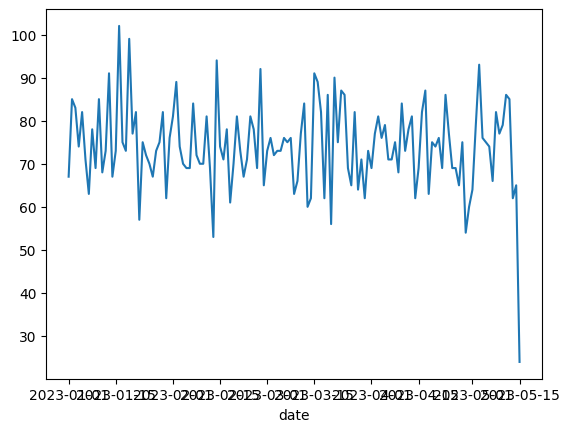

In [8]:
trend.plot()

<Axes: xlabel='date'>

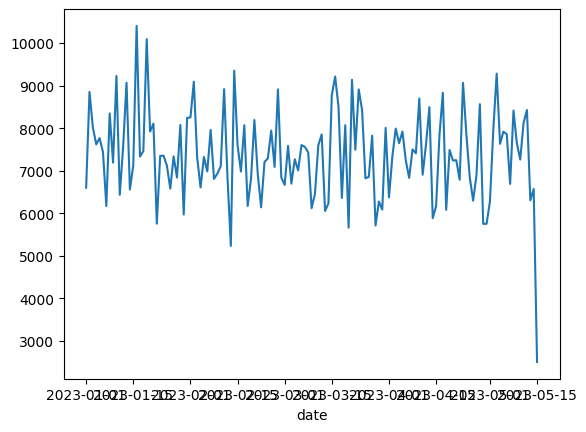

In [9]:
df['engagement']=df['Likes']+df['Retweets']
eng_trend=df.groupby('date')['engagement'].sum()
eng_trend.plot()

<Axes: xlabel='date'>

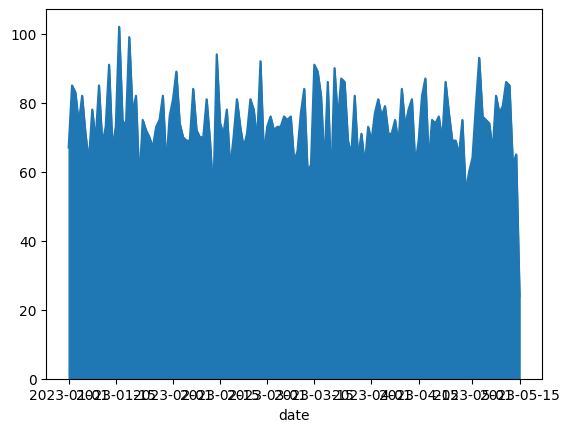

In [10]:
trend.plot(kind='area')

<Axes: xlabel='date'>

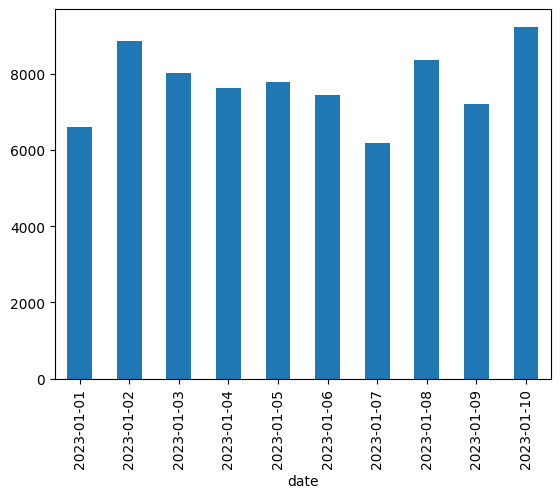

In [12]:
eng_trend[:10].plot(kind='bar')

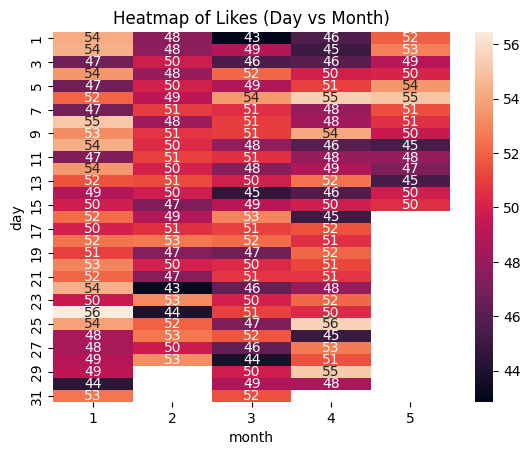

In [14]:
df['day'] = df['Timestamp'].dt.day
df['month'] = df['Timestamp'].dt.month

heatmap_data = df.pivot_table(index='day', columns='month', values='Likes', aggfunc='mean')

sns.heatmap(heatmap_data, annot=True)
plt.title("Heatmap of Likes (Day vs Month)")
plt.show()